# 0 | Benchmark

This notebook will outline a process for benchmarking the import speed as we implement each of the 3 ideas for improving memory size partitioning:
1. fixed length columns: use known size instead of computing per row
2. vectorized methods: to get size/length of dynamic length columns (if such methods exist)
3. size calcs per histogram pixel: instead of per row

The structure of the notebook is as follows:
- First, we will establish a baseline against which to test.
- Then, we will break out into 3 sections, and run a new benchmarking trial (on the corresponding branch), and record timings.
- Compare results.

In [1]:
import os
import time
import socket
from pathlib import Path

import lsdb
import matplotlib.patches as mpatches
from dask.distributed import Client
from hats_import.pipeline import pipeline_with_client
from hats_import.catalog.arguments import ImportArguments


output_dir = Path("/sdf/data/rubin/user/olynn/mem_size_dp2")

In [2]:
# Make a dask client; set up dashboard for slacd

client = Client(
    n_workers=8,
    # threads_per_worker=2,
    memory_limit="40GB",
)

username = os.getenv("USER")
current_compute_node = socket.gethostname()
dashboard_port = client.scheduler_info()['services']['dashboard']

print(f"Run this in a local shell:")
print(f"  ssh -L 8787:{current_compute_node}:{dashboard_port} -J {username}@s3dflogin.slac.stanford.edu {username}@{current_compute_node}")
print(f"\nThen open: http://localhost:8787/status")

Run this in a local shell:
  ssh -L 8787:sdfiana032:8787 -J olynn@s3dflogin.slac.stanford.edu olynn@sdfiana032

Then open: http://localhost:8787/status


In [3]:
import subprocess, hats_import, hats, os


def _repo_state(path):
    branch = subprocess.check_output(["git", "rev-parse", "--abbrev-ref", "HEAD"], cwd=path).decode().strip()
    commit = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], cwd=path).decode().strip()
    dirty = bool(subprocess.check_output(["git", "status", "--porcelain"], cwd=path).decode().strip())
    return branch, commit, dirty


def print_repo_states():
    hats_import_pkg_dir = os.path.dirname(hats_import.__file__)
    hats_pkg_dir = os.path.dirname(hats.__file__)

    for pkg_dir in [hats_import_pkg_dir, hats_pkg_dir]:
        KERNEL_BRANCH, KERNEL_COMMIT, KERNEL_DIRTY = _repo_state(pkg_dir)
        print(f"kernel is running: {KERNEL_BRANCH}@{KERNEL_COMMIT}{' (dirty)' if KERNEL_DIRTY else ''}")


print_repo_states()

kernel is running: issue/hi-671/mem-size-opt@8fbd64a
kernel is running: issue/hi-671/mem-size-opt@aa4fc04c


## 0.Baseline

*Run the first trial using lsdb main; record the time taken to re-import each of 4 cone searchs.*

### Create trial catalogs

**Catalog:** DP2
  - Has LCs
  - Has plenty of fixed len cols

**Cone search regions:** (thanks Kostya!)  
- ra=170, dec=-25
- ra=255, dec=40

**Dask parameters:**  
- n workers: 32
- threads per worker: 2
- mem per worker: 14GB

/sdf/home/o/olynn/hats/src/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


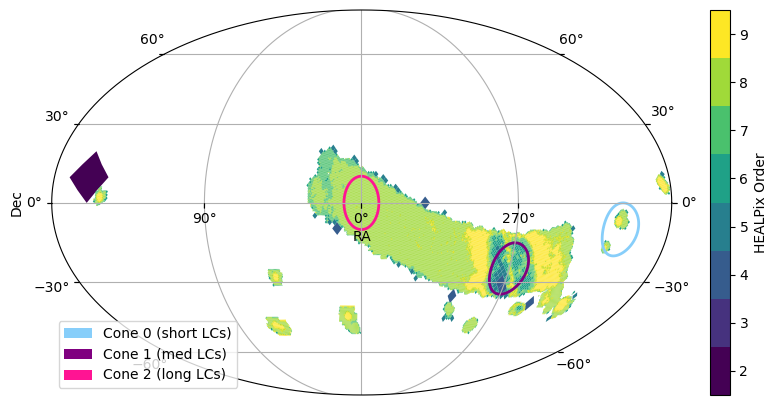

In [6]:
# Load DP2 object and define cone search regions
 
dp2_obj = lsdb.open_catalog("/sdf/data/rubin/shared/lsdb_commissioning/hats/dp2/object_collection")

fig, ax = dp2_obj.plot_pixels(plot_title="DP2 Obj")

handles = []
colors = ["lightskyblue", "purple", "deeppink", "tomato"]
labels = ["Cone 0 (short LCs)", "Cone 1 (med LCs)", "Cone 2 (long LCs)", "Cone 3 (mixed LCs)"]
cones = [
    lsdb.ConeSearch(ra=-150, dec=-10, radius_arcsec=10 * 3600),
    lsdb.ConeSearch(ra=270, dec=-25, radius_arcsec=10 * 3600),
    lsdb.ConeSearch(ra=0, dec=0, radius_arcsec=10 * 3600),
    # lsdb.ConeSearch(ra=10.7, dec=41.3, radius_arcsec=7 * 3600)  # mixed LCs (M31)
]

for i, cone in enumerate(cones):
    cone.plot(ec=colors[i], fc="#00000000", linewidth=2, ax=ax, fig=fig)
    handles.append(mpatches.Patch(fc=colors[i], linewidth=2, label=labels[i]),)

ax.legend(loc="lower left", handles=handles)

In [ ]:
# Generate initial benchmark catalogs

for i, cone in enumerate(cones):
    print(f"Generating catalog {i}...")
    dp2_obj.search(cone).write_catalog(
        base_catalog_path=f"{output_dir}/cat_{i}",
        catalog_name=f"cat_{i}",
        as_collection=False,
    )

Generating catalog 0...
Generating catalog 1...
Generating catalog 2...


In [ ]:
# Check the catalogs are big enough to be meaningful

!echo "Overall catalog sizes:"
!du -h --max-depth=1 {output_dir} | sort -rh

!echo "Top 5 files in short-LC catalog:"
!find {output_dir}/ -type f | xargs du -h | sort -rh | head -n 5

Overall catalog sizes:
109G	/sdf/data/rubin/user/olynn/mem_size_dp2
56G	/sdf/data/rubin/user/olynn/mem_size_dp2/cat_2
37G	/sdf/data/rubin/user/olynn/mem_size_dp2/cat_0
17G	/sdf/data/rubin/user/olynn/mem_size_dp2/cat_1
Top 5 files in short-LC catalog:
87M	/sdf/data/rubin/user/olynn/mem_size_dp2/cat_1/dataset/Norder=7/Dir=110000/Npix=115654.parquet
84M	/sdf/data/rubin/user/olynn/mem_size_dp2/cat_1/dataset/Norder=8/Dir=460000/Npix=462601.parquet
81M	/sdf/data/rubin/user/olynn/mem_size_dp2/cat_1/dataset/Norder=7/Dir=110000/Npix=115651.parquet
81M	/sdf/data/rubin/user/olynn/mem_size_dp2/cat_1/dataset/Norder=7/Dir=110000/Npix=115562.parquet
80M	/sdf/data/rubin/user/olynn/mem_size_dp2/cat_1/dataset/Norder=7/Dir=110000/Npix=115663.parquet
sort: write failed: 'standard output': Broken pipe
sort: write error


### Run initial benchmark

In [20]:
!rm -r {output_dir}/initial*

In [21]:
!tree -L 1 {output_dir}


/sdf/data/rubin/user/olynn/mem_size_dp2
├── cat_0
├── cat_1
└── cat_2

3 directories, 0 files


In [ ]:
# Record what branch we'ew on (for initial run, should be main
print_repo_states()

# Run each trial
trial_times = []
for i in range(3):
    print(f"Starting initial benchmark for cat {i}...")
    start = time.perf_counter()
    args = ImportArguments.reimport_from_hats(
        f"{output_dir}/cat_{i}",
        f"{output_dir}/initial_{i}",
        output_artifact_name=f"initial_{i}",
        byte_pixel_threshold=1_000_000_000,  # 1GB
        progress_bar=False,
    )
    pipeline_with_client(args, client)
    elapsed = time.perf_counter() - start
    
    print(f"Cat {i} completed in {elapsed} seconds.")
    trial_times.append(elapsed)

In [23]:
for i, seconds in enumerate(trial_times):
    m, s = divmod(seconds, 60)
    print(f"Cat {i} ran in {int(m):2d}m {s:4.1f}s")

Cat 0 ran in 42m 51.6s
Cat 1 ran in 17m 30.9s
Cat 2 ran in 53m 31.1s


In [ ]:
"""
Cat 0 ran in 42m 51.6s
Cat 1 ran in 17m 30.9s
Cat 2 ran in 53m 31.1s
"""

## Optimizations: 
- Fixed length columns
  - While rewriting the mem size calculations, switched to doing it col-wise, not row-by-row
- Additionally,	consider sometimes classifying strings as fixed length cols. 
  - We can first check how much they vary in our first, single-chunk sample
  - And if it is not too much (as in, they represent a single number), consider them as fixed len cols
- Run precomputation before the mapping stage, rather than in it
  - This should show performance benefits for catalogs with many smaller single-chunk files
- Nested cols should typically have fixed len subcols. 
  - We should just count the length of the top nested col, mult by the len of the subcol, etc.
- And more, to do: add


In [4]:
print_repo_states()

kernel is running: issue/hi-671/mem-size-opt@8fbd64a
kernel is running: issue/hi-671/mem-size-opt@aa4fc04c


In [16]:
!tree -L 1 {output_dir}

/sdf/data/rubin/user/olynn/mem_size_dp2
├── cat_0
├── cat_1
├── cat_2
├── initial_0
├── initial_1
└── initial_2

6 directories, 0 files


In [ ]:
# optimized_0: "/sdf/data/rubin/user/olynn/mem_size_dp2/optimized_0/optimized_0"
# optimized_1: "/sdf/data/rubin/user/olynn/mem_size_dp2/optimized_1/optimized_1"
# optimized_2: "/sdf/data/rubin/user/olynn/mem_size_dp2/optimized_2/optimized_2"

In [17]:
trial_times = []

for i in range(3):
    start = time.perf_counter()
    args = ImportArguments.reimport_from_hats(
        f"{output_dir}/cat_{i}",
        f"{output_dir}/optimized_{i}",
        output_artifact_name=f"optimized_{i}",
        byte_pixel_threshold=1_000_000_000,  # 1GB
        progress_bar=False,
    )
    pipeline_with_client(args, client)
    elapsed = time.perf_counter() - start

    print(f"Trial {i} completed in {elapsed} seconds.")
    trial_times.append(elapsed)

Trial 0 completed in 431.1631688810885 seconds.
Trial 1 completed in 166.43666184390895 seconds.
Trial 2 completed in 451.1695491450373 seconds.


In [18]:
for i, seconds in enumerate(trial_times):
    m, s = divmod(seconds, 60)
    print(f"Trial {i} ran in {int(m):2d}m {s:4.1f}s")

Trial 0 ran in  7m 11.2s
Trial 1 ran in  2m 46.4s
Trial 2 ran in  7m 31.2s


In [ ]:
"""
Trial 0 ran in  7m 11.2s
Trial 1 ran in  2m 46.4s
Trial 2 ran in  7m 31.2s
"""

## Comparison

In [19]:
import numpy as np
import matplotlib.pyplot as plt


def to_seconds(m, s):
    return m * 60 + s

baseline_times = [2572, 1051, 3211]
opt_times = [432, 166, 451]

# Sizes by initial, baseline, and optimized runs
cat_0_sizes = [37, 33, 34]  # GB
cat_1_sizes = [17, 13, 13]  # GB
cat_2_sizes = [56, 41, 42]  # GB

stages = ["Baseline","Optimized"]
times_by_stage = [baseline_times, opt_times]
n_trials = len(baseline_times)


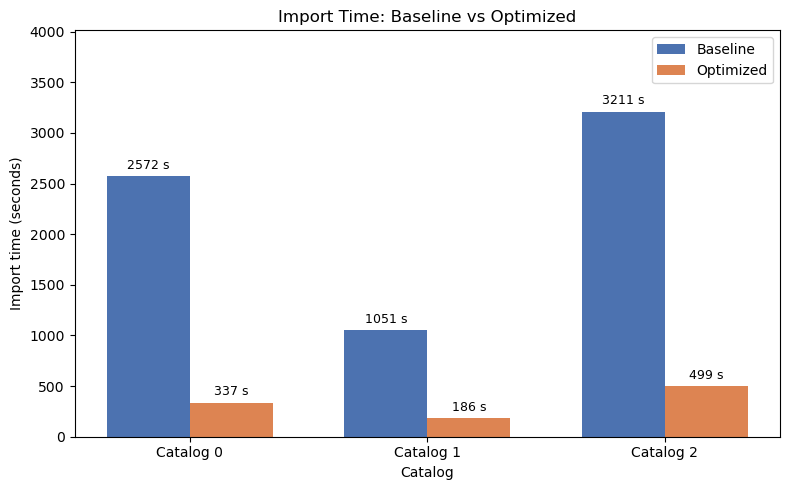

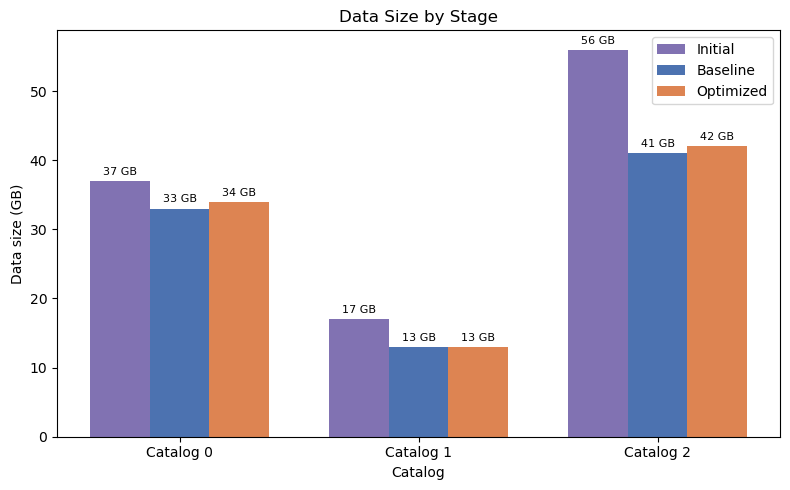

Summary:
  Catalog 0: 7.6x faster, 8.1% smaller (initial→optimized)
  Catalog 1: 5.7x faster, 23.5% smaller (initial→optimized)
  Catalog 2: 6.4x faster, 25.0% smaller (initial→optimized)


In [20]:
import numpy as np
import matplotlib.pyplot as plt


def to_seconds(m, s):
    return m * 60 + s


# --- Data ---
baseline_times = [2572, 1051, 3211]  # seconds, per catalog
opt_times = [337, 186, 499]  # seconds, per catalog

cat_0_sizes = [37, 33, 34]  # GB — initial, baseline, optimized
cat_1_sizes = [17, 13, 13]  # GB
cat_2_sizes = [56, 41, 42]  # GB

catalog_labels = ["Catalog 0", "Catalog 1", "Catalog 2"]
n_trials = len(baseline_times)

# =========================================================
# Plot 1: Import time — baseline vs optimized, per catalog
# =========================================================
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(n_trials)
width = 0.35

bars_baseline = ax.bar(x - width / 2, baseline_times, width, label="Baseline", color="#4C72B0")
bars_opt = ax.bar(x + width / 2, opt_times, width, label="Optimized", color="#DD8452")

ax.set_xlabel("Catalog")
ax.set_ylabel("Import time (seconds)")
ax.set_title("Import Time: Baseline vs Optimized")
ax.set_xticks(x)
ax.set_xticklabels(catalog_labels)
ax.legend()

for bars in (bars_baseline, bars_opt):
    ax.bar_label(bars, fmt="%.0f s", padding=3, fontsize=9)

for i in range(n_trials):
    speedup = baseline_times[i] / opt_times[i]
    y = max(baseline_times[i], opt_times[i]) * 1.08
    # ax.text(x[i], y, f"{speedup:.1f}x faster", ha="center", fontsize=10, fontweight="bold")

ax.set_ylim(0, max(baseline_times) * 1.25)
plt.tight_layout()
plt.savefig("import_time_speedup.png", dpi=150)
plt.show()

# =========================================================
# Plot 2: Data size reduction — initial vs baseline vs optimized
# =========================================================
sizes_by_catalog = [cat_0_sizes, cat_1_sizes, cat_2_sizes]
stage_labels = ["Initial", "Baseline", "Optimized"]
stage_colors = ["#8172B2", "#4C72B0", "#DD8452"]

fig, ax = plt.subplots(figsize=(8, 5))

width = 0.25
x = np.arange(n_trials)

for i, (stage, color) in enumerate(zip(stage_labels, stage_colors)):
    values = [sizes_by_catalog[c][i] for c in range(n_trials)]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, values, width, label=stage, color=color)
    ax.bar_label(bars, fmt="%.0f GB", padding=3, fontsize=8)

ax.set_xlabel("Catalog")
ax.set_ylabel("Data size (GB)")
ax.set_title("Data Size by Stage")
ax.set_xticks(x)
ax.set_xticklabels(catalog_labels)
ax.legend()

plt.tight_layout()
# plt.savefig("data_size_reduction.png", dpi=150)
plt.show()

# =========================================================
# Summary printout
# =========================================================
print("Summary:")
for i in range(n_trials):
    speedup = baseline_times[i] / opt_times[i]
    size_reduction = (1 - sizes_by_catalog[i][2] / sizes_by_catalog[i][0]) * 100
    print(f"  {catalog_labels[i]}: {speedup:.1f}x faster, {size_reduction:.1f}% smaller (initial→optimized)")
